# 1 — Fit LG to a single real network (SNAP ego graph)

Fast end-to-end check that the corrected `LogitGraphFitter` and
`GraphModelComparator` produce sane fits on a real social network.

The fits below all use the post-`4f883e0` corrections:
- σ estimated via Layer-2 + `feature_mode="incremental"` offset logit
- d=0 generation short-circuits to direct ER at `p = expit(σ̂)`
- d≥1 Gibbs is warm-started near `clip(expit(σ̂), 0.02, 0.5)`

**Default dataset:** Facebook ego network `3980` from the SNAP
`ego-Facebook` collection (`data/misc/facebook/3980.edges`, ~52 nodes,
~146 edges). Switch by editing the `DATASET` block in the second cell.
Supported sources (already present in `data/misc/`):
- `facebook/<id>.edges` — Leskovec ego-Facebook (small)
- `twitter/<id>.edges` — Leskovec ego-Twitter (small/medium)
- `gplus/<id>.edges` — Leskovec ego-G+ (large; not recommended for this fast notebook)
- `twitch/graphs_processed/<COUNTRY>_graph.edges` — Musaé Twitch (larger)

Should finish in well under a minute on the default dataset.

In [1]:
import os
for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from logit_graph import (
    LogitGraphFitter,
    GraphModelComparator,
    calculate_graph_attributes,
)
from logit_graph.gic import GraphInformationCriterion

SEED = 0
np.random.seed(SEED)

# ---- DATASET selection ----------------------------------------------------
# Change DATASET to any of the keys below to switch networks.
DATA_ROOT = Path("..") / ".." / "data"
DATASETS = {
    "facebook_3980": DATA_ROOT / "misc" / "facebook" / "3980.edges",
    "facebook_698":  DATA_ROOT / "misc" / "facebook" / "698.edges",
    "facebook_414":  DATA_ROOT / "misc" / "facebook" / "414.edges",
    "twitter_101859065": DATA_ROOT / "misc" / "twitter" / "101859065.edges",
    "twitter_10146102":  DATA_ROOT / "misc" / "twitter" / "10146102.edges",
    "twitch_ENGB": DATA_ROOT / "twitch" / "graphs_processed" / "ENGB_graph.edges",
}
DATASET = "facebook_3980"   # ← change me

edge_path = DATASETS[DATASET].resolve()
assert edge_path.is_file(), f"Missing dataset file: {edge_path}"

def _load_edges(path: Path) -> nx.Graph:
    G = nx.read_edgelist(path, nodetype=int)
    G = nx.Graph(G)                     # ensure undirected, no parallel edges
    G.remove_edges_from(nx.selfloop_edges(G))
    if G.number_of_nodes() == 0:
        raise ValueError(f"Empty graph loaded from {path}")
    # Take the largest connected component so spectrum/path-length attributes are well-defined.
    cc = max(nx.connected_components(G), key=len)
    return G.subgraph(cc).copy()

G_real = _load_edges(edge_path)
G_real = nx.convert_node_labels_to_integers(G_real)

print(f"DATASET={DATASET}  file={edge_path}")
print(
    f"  n={G_real.number_of_nodes()}, |E|={G_real.number_of_edges()}, "
    f"density={nx.density(G_real):.4f}"
)
print(calculate_graph_attributes(G_real))

DATASET=facebook_3980  file=/Users/maruanottoni/home/master/research/all_logit/logit-graph/data/misc/facebook/3980.edges
  n=44, |E|=138, density=0.1459
{'nodes': 44, 'edges': 138, 'density': 0.14587737843551796, 'avg_clustering': 0.45476809657959394, 'assortativity': 0.05297863564191894, 'num_components': 1, 'largest_component_size': 44, 'avg_path_length': 2.5665961945031714, 'diameter': 5}


## 1. Fit a single LG with `LogitGraphFitter`

Single `d=2` run — `LogitGraphFitter` now uses the corrected estimator
(Layer-2 + incremental features) and the corrected generator (d=0 ER
short-circuit + warm-start for d≥1, both applied inside `_generate_graph`).

In [2]:
fitter = LogitGraphFitter(
    d=2,
    n_iteration=5000,
    patience=500,
    dist_type="KL",
    min_gic_threshold=5,
    er_p=0.05,
    verbose=False,
).fit(G_real)

print(f"fit_success    : {fitter.metadata['fit_success']}")
print(f"sigma_hat      : {fitter.metadata['sigma']:.4f}")
print(f"GIC (LG, d=2)  : {fitter.metadata['gic_value']:.4f}")
print(f"best_iteration : {fitter.metadata['best_iteration']}")
print(f"fitted edges   : {fitter.metadata['fitted_edges']}  (real={G_real.number_of_edges()})")

fit_success    : True
sigma_hat      : -4.2134
GIC (LG, d=2)  : 40.1340
best_iteration : 2700
fitted edges   : 20  (real=138)


## 2. GIC-based comparison: LG (best d) vs ER / WS / BA

`GraphModelComparator` searches d ∈ {0,1,2,3} for LG and compares
spectral GIC against grid-searched baselines. Lower GIC = better fit.

In [3]:
comparator = GraphModelComparator(
    d_list=[0, 1, 2, 3],
    lg_params={
        "max_iterations": 5000,
        "patience": 500,
        "edge_delta": None,
        "min_gic_threshold": 5,
        "er_p": 0.05,
        "check_interval": 50,
    },
    other_model_n_runs=2,
    dist_type="KL",
    verbose=False,
    other_models=["ER", "WS", "BA"],
    other_model_grid_points=5,
).compare(original_graph=G_real, graph_filepath=DATASET)

summary = comparator.summary_df.copy()
display_cols = [
    "model", "param", "gic_value", "nodes", "edges", "density",
    "avg_clustering", "assortativity",
]
summary[display_cols].sort_values("gic_value")

Testing the selected model for ER
ER gic: 5.7399772738790364
Testing the selected model for WS
WS gic: 10.375913708889021
Testing the selected model for BA
BA gic: 12.444506804653162


,model,param,gic_value,nodes,edges,density,avg_clustering,assortativity
2,ER,0.13,5.739977,44,123,0.130021,0.138763,0.010729
3,WS,80.3775,10.375914,44,132,0.139535,0.141842,-0.169683
1,LG,"d=0, sigma=-1.7673",10.710271,44,135,0.142706,0.159207,-0.017430
4,BA,6.25,12.444507,44,228,0.241015,0.344018,-0.190577
0,Original,N/A,NaN,44,138,0.145877,0.454768,0.052979


## 3. GIC bar chart

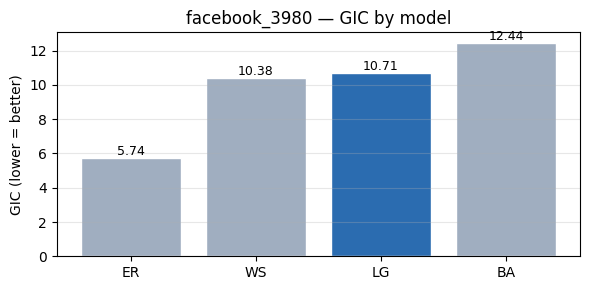

Best model by GIC: ER (param=0.13, GIC=5.740)


In [4]:
scored = summary[summary["model"] != "Original"].dropna(subset=["gic_value"])
scored = scored.sort_values("gic_value")

fig, ax = plt.subplots(figsize=(6.0, 3.0))
colors = ["#2b6cb0" if m == "LG" else "#a0aec0" for m in scored["model"]]
ax.bar(scored["model"], scored["gic_value"], color=colors, edgecolor="white")
for i, (m, v) in enumerate(zip(scored["model"], scored["gic_value"])):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("GIC (lower = better)")
ax.set_title(f"{DATASET} — GIC by model")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

best = scored.iloc[0]
print(f"Best model by GIC: {best['model']} (param={best['param']}, GIC={best['gic_value']:.3f})")

## 4. Side-by-side network layouts

The real graph is laid out once; every fitted graph uses the same
spring layout *over its own node set* so structural differences are
visually comparable but not over-aligned.

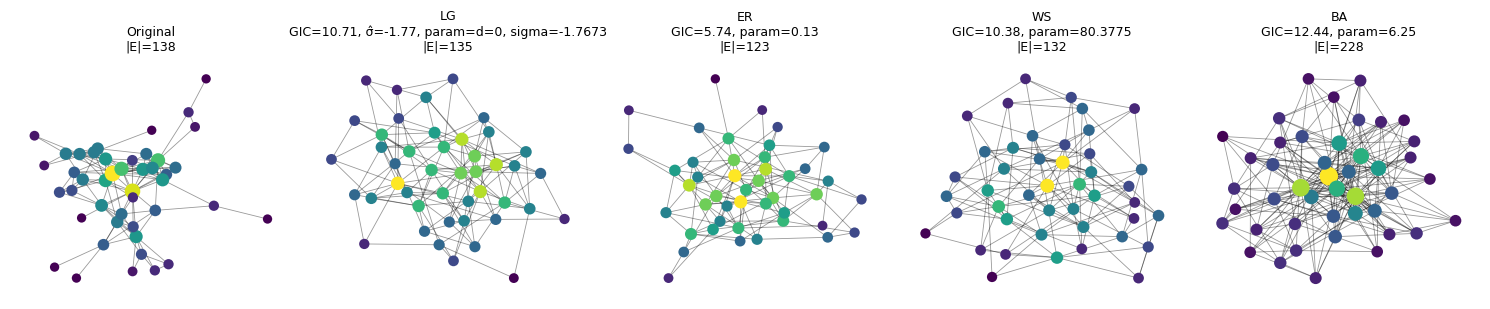

In [5]:
panels = [("Original", G_real)]
for name in ["LG", "ER", "WS", "BA"]:
    data = comparator.fitted_graphs_data.get(name, {})
    G_fit = data.get("graph")
    if G_fit is not None:
        panels.append((name, G_fit))

fig, axes = plt.subplots(1, len(panels), figsize=(3.0 * len(panels), 3.2))
if len(panels) == 1:
    axes = [axes]
for ax, (name, G) in zip(axes, panels):
    if G.number_of_edges() > 0:
        pos = nx.spring_layout(G, seed=42, k=None)
    else:
        pos = nx.circular_layout(G)
    deg = np.array([d for _, d in G.degree()])
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=0.6)
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=40 + 5 * deg, node_color=deg,
        cmap="viridis", linewidths=0.0,
    )
    md = comparator.fitted_graphs_data.get(name, {}).get("metadata", {})
    extras = []
    if "gic_value" in md and np.isfinite(md["gic_value"]):
        extras.append(f"GIC={md['gic_value']:.2f}")
    if "sigma" in md:
        extras.append(f"σ̂={md['sigma']:.2f}")
    if name != "Original" and "param" in md:
        extras.append(f"param={md['param']}")
    title = name + ("\n" + ", ".join(extras) if extras else "")
    title += f"\n|E|={G.number_of_edges()}"
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()
fig.tight_layout()
plt.show()

## 5. Normalized-Laplacian spectral density

Each model graph is overlaid against the real graph's spectral density.
Closer overlap with the real (black) curve ↔ smaller spectral distance
↔ smaller GIC.

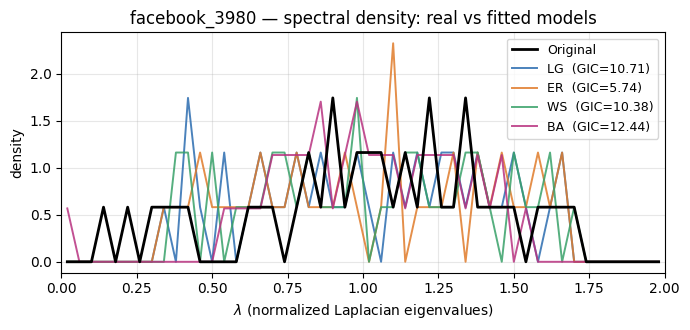

In [6]:
def spectral_density(G: nx.Graph) -> tuple[np.ndarray, np.ndarray]:
    gic = GraphInformationCriterion(graph=G, model="LG", log_graph=G, dist="KL")
    hist, bin_edges = gic.compute_spectral_density(G)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return centers, hist

x_real, y_real = spectral_density(G_real)

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.plot(x_real, y_real, color="black", lw=2.0, label="Original", zorder=5)

palette = {"LG": "#2b6cb0", "ER": "#e07b2a", "WS": "#38a169", "BA": "#b83280"}
for name in ["LG", "ER", "WS", "BA"]:
    G = comparator.fitted_graphs_data.get(name, {}).get("graph")
    if G is None or G.number_of_edges() == 0:
        continue
    x, y = spectral_density(G)
    gic_v = comparator.fitted_graphs_data[name]["metadata"].get("gic_value", float("nan"))
    ax.plot(x, y, color=palette[name], lw=1.4, alpha=0.85,
            label=f"{name}  (GIC={gic_v:.2f})")

ax.set_xlim(0, 2)
ax.set_xlabel(r"$\lambda$ (normalized Laplacian eigenvalues)")
ax.set_ylabel("density")
ax.set_title(f"{DATASET} — spectral density: real vs fitted models")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Final scoreboard

GIC, density, average clustering, and assortativity for each model
ranked by GIC.

In [7]:
real_attrs = {
    "density": nx.density(G_real),
    "avg_clustering": nx.average_clustering(G_real),
    "assortativity": nx.degree_assortativity_coefficient(G_real),
}

rows = [{
    "model": "Original",
    "gic": np.nan,
    "edges": G_real.number_of_edges(),
    "density": real_attrs["density"],
    "avg_clustering": real_attrs["avg_clustering"],
    "assortativity": real_attrs["assortativity"],
    "Δdensity": 0.0,
    "Δclustering": 0.0,
}]
for name in ["LG", "ER", "WS", "BA"]:
    data = comparator.fitted_graphs_data.get(name, {})
    G = data.get("graph")
    if G is None:
        continue
    a = {
        "density": nx.density(G),
        "avg_clustering": nx.average_clustering(G),
        "assortativity": nx.degree_assortativity_coefficient(G),
    }
    rows.append({
        "model": name,
        "gic": data["metadata"].get("gic_value", np.nan),
        "edges": G.number_of_edges(),
        "density": a["density"],
        "avg_clustering": a["avg_clustering"],
        "assortativity": a["assortativity"],
        "Δdensity": a["density"] - real_attrs["density"],
        "Δclustering": a["avg_clustering"] - real_attrs["avg_clustering"],
    })

scoreboard = pd.DataFrame(rows)
scoreboard = pd.concat(
    [scoreboard[scoreboard["model"] == "Original"],
     scoreboard[scoreboard["model"] != "Original"].sort_values("gic")],
    ignore_index=True,
)
scoreboard.round(4)

,model,gic,edges,density,avg_clustering,assortativity,Δdensity,Δclustering
0,Original,NaN,138,0.1459,0.4548,0.0530,0.0000,0.0000
1,ER,5.7400,123,0.1300,0.1388,0.0107,-0.0159,-0.3160
2,WS,10.3759,132,0.1395,0.1418,-0.1697,-0.0063,-0.3129
3,LG,10.7103,135,0.1427,0.1592,-0.0174,-0.0032,-0.2956
4,BA,12.4445,228,0.2410,0.3440,-0.1906,0.0951,-0.1107
